# Propuesta Claude – Remuestreo: Jackknife, Bootstrap y Validación Cruzada

**Simulaciones y Procesos Estocásticos — UCA 2026**

Este notebook implementa los tres métodos de remuestreo principales y los compara con estimaciones analíticas cuando están disponibles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 1. Motivación: el problema del intervalo de confianza para la mediana

Tenemos tiempos de servicio de 30 clientes en una cola. Queremos estimar la **mediana** y su IC.
La fórmula analítica para el IC de la mediana existe pero es complicada. El bootstrap la da gratis.

In [2]:
# Datos simulados: tiempos de servicio Exponencial(lambda=0.5)
lam_true = 0.5
n = 30
datos = np.random.exponential(scale=1/lam_true, size=n)

# Mediana teórica de Exp(lambda): ln(2)/lambda
mediana_teorica = np.log(2) / lam_true
mediana_muestral = np.median(datos)

print(f"Mediana teórica:   {mediana_teorica:.3f}")
print(f"Mediana muestral:  {mediana_muestral:.3f}")
print(f"Media muestral:    {np.mean(datos):.3f}  (comparar con 1/lambda={1/lam_true:.1f})")

Mediana teórica:   1.386
Mediana muestral:  1.035
Media muestral:    1.612  (comparar con 1/lambda=2.0)


## 2. El método Jackknife

In [4]:
def jackknife(datos, estadistico):
    """Estimación Jackknife del sesgo y varianza de un estadístico."""
    n = len(datos)
    theta_hat = estadistico(datos)
    
    # Calcular theta con cada observacion eliminada
    thetas_jack = np.array([
        estadistico(np.delete(datos, i))
        for i in range(n)
    ])
    
    theta_jack_mean = np.mean(thetas_jack)
    
    # Estimaciones
    sesgo = (n - 1) * (theta_jack_mean - theta_hat)
    varianza = ((n - 1) / n) * np.sum((thetas_jack - theta_jack_mean)**2)
    se = np.sqrt(varianza)
    
    return {
        'estimador': theta_hat,
        'sesgo': sesgo,
        'se': se,
        'thetas_jack': thetas_jack
    }

# Jackknife para la mediana
result_jack = jackknife(datos, np.median)
print("=== Jackknife para la mediana ===")
print(f"Estimador:    {result_jack['estimador']:.4f}")
print(f"Sesgo est.:   {result_jack['sesgo']:.4f}")
print(f"Error estándar: {result_jack['se']:.4f}")

# Jackknife para la media (comparación)
result_jack_mean = jackknife(datos, np.mean)
print(f"\nJackknife SE de la media: {result_jack_mean['se']:.4f}")
print(f"SE analítico de la media: {np.std(datos)/np.sqrt(n):.4f}  (deben coincidir)")

=== Jackknife para la mediana ===
Estimador:    1.0348
Sesgo est.:   0.0000
Error estándar: 0.5184

Jackknife SE de la media: 0.3102
SE analítico de la media: 0.3050  (deben coincidir)


## 3. El método Bootstrap

In [5]:
def bootstrap(datos, estadistico, B=1000, alpha=0.05):
    """Bootstrap con IC por percentil."""
    n = len(datos)
    theta_hat = estadistico(datos)
    
    # Muestreo con reposición
    thetas_boot = np.array([
        estadistico(np.random.choice(datos, size=n, replace=True))
        for _ in range(B)
    ])
    
    se_boot = np.std(thetas_boot)
    ic_lower = np.percentile(thetas_boot, 100 * alpha/2)
    ic_upper = np.percentile(thetas_boot, 100 * (1 - alpha/2))
    
    return {
        'estimador': theta_hat,
        'se': se_boot,
        'ic': (ic_lower, ic_upper),
        'thetas_boot': thetas_boot
    }

# Bootstrap para la mediana con distintos B
print("=== Bootstrap para la mediana ===")
for B in [100, 500, 2000]:
    r = bootstrap(datos, np.median, B=B)
    print(f"B={B:5d}: SE={r['se']:.4f}, IC 95%=[{r['ic'][0]:.3f}, {r['ic'][1]:.3f}]")

print(f"\nJackknife SE: {result_jack['se']:.4f} (comparar con bootstrap)")

=== Bootstrap para la mediana ===
B=  100: SE=0.2984, IC 95%=[0.689, 1.656]
B=  500: SE=0.3278, IC 95%=[0.583, 1.810]
B= 2000: SE=0.3247, IC 95%=[0.568, 1.810]

Jackknife SE: 0.5184 (comparar con bootstrap)


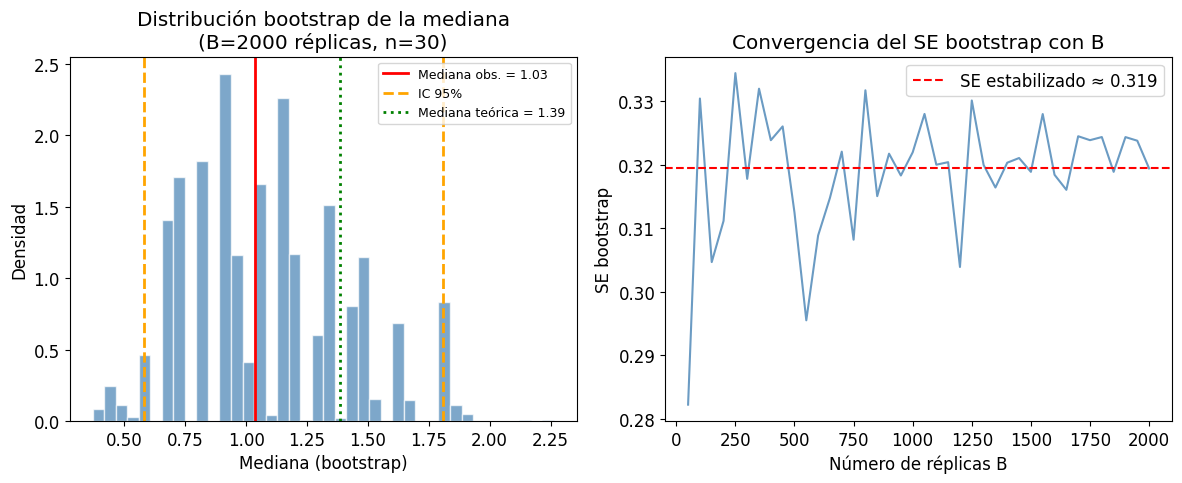

In [6]:
# Visualizar la distribución bootstrap
B = 2000
result_boot = bootstrap(datos, np.median, B=B)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma de medianas bootstrap
ax = axes[0]
ax.hist(result_boot['thetas_boot'], bins=40, density=True, 
        color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(result_boot['estimador'], color='red', lw=2, label=f"Mediana obs. = {result_boot['estimador']:.2f}")
ax.axvline(result_boot['ic'][0], color='orange', lw=2, ls='--', label=f"IC 95%")
ax.axvline(result_boot['ic'][1], color='orange', lw=2, ls='--')
ax.axvline(mediana_teorica, color='green', lw=2, ls=':', label=f"Mediana teórica = {mediana_teorica:.2f}")
ax.set_xlabel("Mediana (bootstrap)")
ax.set_ylabel("Densidad")
ax.set_title(f"Distribución bootstrap de la mediana\n(B={B} réplicas, n={n})")
ax.legend(fontsize=9)

# Convergencia del SE bootstrap con B
ax = axes[1]
Bs = range(50, 2001, 50)
ses = []
for b in Bs:
    r = bootstrap(datos, np.median, B=b)
    ses.append(r['se'])
    
ax.plot(Bs, ses, color='steelblue', alpha=0.8)
ax.axhline(ses[-1], color='red', ls='--', label=f"SE estabilizado ≈ {ses[-1]:.3f}")
ax.set_xlabel("Número de réplicas B")
ax.set_ylabel("SE bootstrap")
ax.set_title("Convergencia del SE bootstrap con B")
ax.legend()

plt.tight_layout()
plt.show()

## 4. Bootstrap vs Jackknife: ¿cuándo falla Jackknife?

El Jackknife falla para estimadores no suaves como la mediana cuando n es pequeño.

In [7]:
# Experimento: comparar SE real (simulado) vs Bootstrap vs Jackknife
# para la mediana y la media

n_exp = 25
M = 5000  # repeticiones del experimento

medianas_sim = []
medias_sim = []

for _ in range(M):
    muestra = np.random.exponential(scale=1/lam_true, size=n_exp)
    medianas_sim.append(np.median(muestra))
    medias_sim.append(np.mean(muestra))

se_real_mediana = np.std(medianas_sim)
se_real_media = np.std(medias_sim)

# Con los datos originales
r_boot_med = bootstrap(datos[:n_exp], np.median, B=2000)
r_jack_med = jackknife(datos[:n_exp], np.median)
r_boot_mean = bootstrap(datos[:n_exp], np.mean, B=2000)
r_jack_mean = jackknife(datos[:n_exp], np.mean)

print("Comparación SE real (simulado) vs. Bootstrap vs. Jackknife")
print(f"\n{'Estadístico':<12} {'SE real':>10} {'Bootstrap':>10} {'Jackknife':>10}")
print("-" * 45)
print(f"{'Mediana':<12} {se_real_mediana:>10.4f} {r_boot_med['se']:>10.4f} {r_jack_med['se']:>10.4f}")
print(f"{'Media':<12} {se_real_media:>10.4f} {r_boot_mean['se']:>10.4f} {r_jack_mean['se']:>10.4f}")
print("\n→ Para la media (suave), Jackknife y Bootstrap dan resultados similares.")
print("→ Para la mediana (no suave), Bootstrap es más cercano al SE real.")

Comparación SE real (simulado) vs. Bootstrap vs. Jackknife

Estadístico     SE real  Bootstrap  Jackknife
---------------------------------------------
Mediana          0.4116     0.3403     0.2653
Media            0.4008     0.3534     0.3600

→ Para la media (suave), Jackknife y Bootstrap dan resultados similares.
→ Para la mediana (no suave), Bootstrap es más cercano al SE real.


## 5. Validación Cruzada k-Fold

In [14]:
# Generar datos para regresión con algo de ruido
np.random.seed(123)
n_reg = 100
X = np.random.uniform(0, 10, n_reg).reshape(-1, 1)
y_true = 2 * X.ravel() + 3
y = y_true + np.random.normal(0, 2, n_reg)  # ruido gaussiano

# Evaluación con CV
modelo = LinearRegression()

print("=== Validación cruzada para regresión lineal ===")
print(f"\n{'k':>10} {'CV Error (MSE)':>20} {'SD':>5}")
print("-" * 38)

for k in [2, 5, 10, n_reg]:  # n_reg = LOOCV
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(modelo, X, y, cv=kf, scoring='neg_mean_squared_error')
    mse_cv = -scores.mean()
    mse_sd = scores.std()
    nombre = f"k={k}" if k != n_reg else f"k={k} (LOOCV)"
    print(f"{nombre:>15} {mse_cv:>10.3f} ± {mse_sd:>6.3f}")

print(f"\nVarianza real del ruido: {4:.3f} (sigma²=4)")

=== Validación cruzada para regresión lineal ===

         k       CV Error (MSE)    SD
--------------------------------------
            k=2      4.373 ±  0.329
            k=5      4.035 ±  0.990
           k=10      3.982 ±  1.346
  k=100 (LOOCV)      3.992 ±  5.755

Varianza real del ruido: 4.000 (sigma²=4)


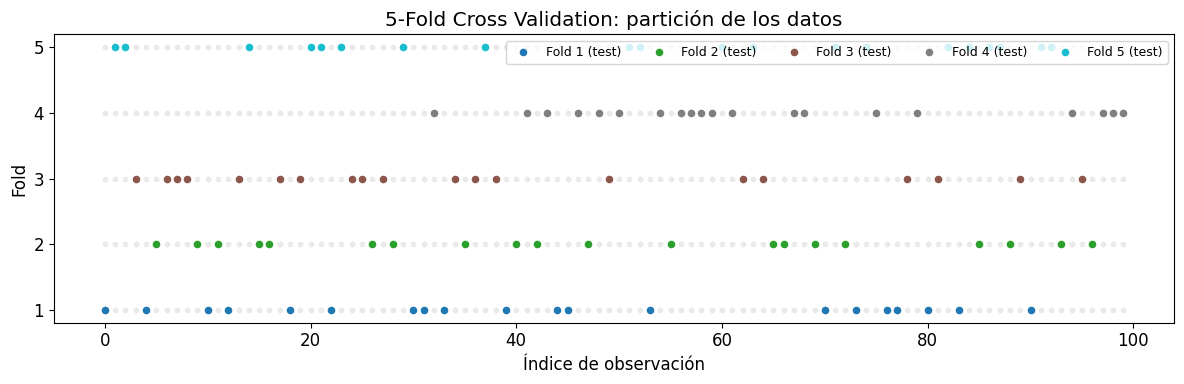

In [15]:
# Visualizar k-Fold CV
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(12, 4))

colors = plt.cm.tab10(np.linspace(0, 1, k))
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
    ax.scatter(test_idx, [fold_idx + 1] * len(test_idx), 
               c=[colors[fold_idx]], s=20, label=f"Fold {fold_idx+1} (test)")
    ax.scatter(train_idx, [fold_idx + 1] * len(train_idx),
               c='lightgray', s=10, alpha=0.4)

ax.set_xlabel("Índice de observación")
ax.set_ylabel("Fold")
ax.set_title(f"{k}-Fold Cross Validation: partición de los datos")
ax.legend(loc='upper right', fontsize=9, ncol=k)
ax.set_yticks(range(1, k+1))
plt.tight_layout()
plt.show()

## 6. Bootstrap como Monte Carlo de la distribución empírica

El bootstrap ES una simulación de Monte Carlo. La 'población' es la distribución empírica Fₙ.

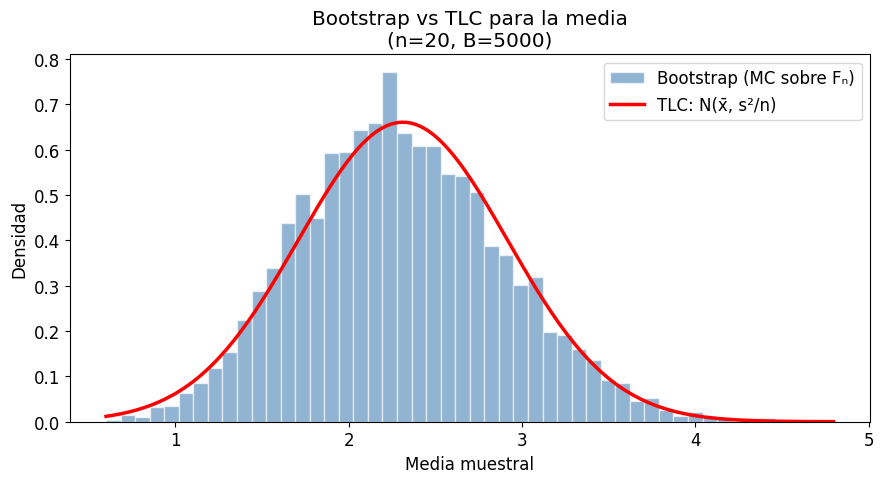

Bootstrap: media=2.3045, SE=0.5902
TLC:       media=2.3129, SE=0.6038


In [16]:
# Demostración: Bootstrap = Monte Carlo de Fn
# Comparar distribución bootstrap de la media con la distribución
# teórica dada por el TLC

n_demo = 20
muestra_demo = np.random.exponential(scale=2, size=n_demo)
B_demo = 5000

# Distribución bootstrap de la media
medias_boot = np.array([
    np.mean(np.random.choice(muestra_demo, size=n_demo, replace=True))
    for _ in range(B_demo)
])

# Distribución teórica (TLC): N(x_bar, s²/n)
x_bar = np.mean(muestra_demo)
s = np.std(muestra_demo, ddof=1)
x_grid = np.linspace(medias_boot.min(), medias_boot.max(), 200)
densidad_tlc = stats.norm.pdf(x_grid, loc=x_bar, scale=s/np.sqrt(n_demo))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(medias_boot, bins=50, density=True, alpha=0.6, color='steelblue',
        edgecolor='white', label='Bootstrap (MC sobre Fₙ)')
ax.plot(x_grid, densidad_tlc, 'r-', lw=2.5, label='TLC: N(x̄, s²/n)')
ax.set_xlabel("Media muestral")
ax.set_ylabel("Densidad")
ax.set_title(f"Bootstrap vs TLC para la media\n(n={n_demo}, B={B_demo})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Bootstrap: media={medias_boot.mean():.4f}, SE={medias_boot.std():.4f}")
print(f"TLC:       media={x_bar:.4f}, SE={s/np.sqrt(n_demo):.4f}")

## Resumen

- **Jackknife**: leave-one-out, O(n) operaciones. Funciona bien para estadísticos suaves.
- **Bootstrap**: muestreo con reposición, O(B·n). Más robusto, funciona para estadísticos no suaves.
- **k-Fold CV**: remuestreo para estimar error de generalización de modelos predictivos.
- **Bootstrap = Monte Carlo**: muestrear de Fₙ es equivalent a Monte Carlo sobre la distribución empírica.